# Task 3: GRPO experiments
The experiment pipeline is implemented in `task3_grpo/`. This notebook inspects saved results on CPU and provides GPU reproduction commands, disabled by default.

Standard GRPO uses online rollouts. Original online normalization forks have equal maximum allowances but different actual token counts. The supplementary fixed-rollout forks train on the same frozen-midpoint rollout pool, with exactly matched generated and active-loss tokens; later batches are not sampled from the updated forks.

Shared rollout generation occurs once; its cost is recorded separately from fork optimization and evaluation. Raw sampled log-probability differences under tempered/top-p decoding are diagnostics. Gradient-allocation statistics refer to selected-token log probabilities, excluding KL, rather than model-parameter gradient norms.


In [ ]:
from pathlib import Path
import os
import subprocess
import sys

if Path('task1_dpo').is_dir():
    repo = Path.cwd()
elif (Path.cwd().parent / 'task1_dpo').is_dir():
    repo = Path.cwd().parent
else:
    from google.colab import drive
    drive.mount('/content/drive')
    repo = Path('/content/drive/MyDrive/ATML/PA2/ATML-PA2-LLM-PostTraining')
assert (repo / 'task1_dpo').is_dir(), f'Repository not found: {repo}'
os.chdir(repo)
print('Repository:', repo)


In [2]:
# Enable for a fresh reproduction; requires network access.
RUN_SETUP = False
if RUN_SETUP:
    subprocess.run([sys.executable, "-m", "pip", "uninstall", "-y", "torchao"], check=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "-r", "requirements.txt"], check=True)
    subprocess.run([sys.executable, "-m", "scripts.download_assets"], check=True)
    subprocess.run([sys.executable, "-m", "scripts.validate_assets"], check=True)


In [3]:
# CPU validation of existing completed experiments.
for module in ["task3_grpo.validate_objective", "task3_grpo.analyze_group_size",
               "task3_grpo.validate_artifacts", "task3_grpo.finalize_matched"]:
    command = [sys.executable, "-m", module]
    if module != "task3_grpo.validate_objective":
        command += ["--config", "configs/grpo.yaml"]
    result = subprocess.run(command, capture_output=True, text=True)
    print(result.stdout)
    print(result.stderr)
    result.check_returncode()


PASS: within-prompt grouping, constant groups, PPO clipping signs, normalization gradients, and truncation masks.


{
  "cache_sha256": "d43024a41301a0b1de63d9bce3f484f8259263dd6495253dd52fecaf73fbbf9c",
  "num_prompts": 24,
  "epsilon": 1e-06,
  "partition_rule": "For each prompt, sort generation_index 0..7, partition consecutive K-sized blocks; reuse all eight completions at every K.",
  "reward_rule": "Use supplied raw reward; all cached completions retained, including capped responses. No new generations.",
  "difficulty_rule": "Full K=8 mean reward per prompt, pooled median threshold; lower <= median, higher > median. Proxy for reward difficulty, not ground-truth correctness.",
  "difficulty_threshold": 2.19873046875,
  "difficulty_bin_source_indices": {
    "lower_mean_reward": [
      175,
      254,
      280,
      457,
      495,
      510,
      671,
      796,
      873,
      936,
      953,
      961
    ],
    "higher_mean_reward": [
      124,
      184,
      185,
    

In [4]:
import pandas as pd
from IPython.display import display

result = subprocess.run([sys.executable, "-m", "task3_grpo.plot_results",
                         "--config", "configs/grpo.yaml"], capture_output=True, text=True)
print(result.stdout)
print(result.stderr)
result.check_returncode()
results = Path("results/task3_grpo")
for name in ["grpo_comparison", "group_size_comparison",
             "matched_normalization_comparison", "matched_gradient_comparison"]:
    print("\n", name)
    display(pd.read_csv(results / f"{name}.csv"))


Saved six PNG/PDF figure pairs, four CSV tables, and original/matched qualitative candidates.



 grpo_comparison


,name,num_eval_prompts,reward_model_score_mean,response_length_mean,response_length_std,generation_cap_rate,sampled_kl_token_mean,entropy_token_mean,updates,generated_tokens,active_loss_tokens,wall_seconds,peak_vram_gib,no_active_token_updates,skipped_policy_steps
0,standard,200,1.505288,311.865,258.245439,0.100,0.000056,1.017092,20,16674,8994,464.468930,6.958502,2,0
1,canonical,200,1.592058,308.775,252.167136,0.070,0.000015,1.021915,8,3314,2802,108.988817,6.704796,0,0
2,dr_grpo,200,1.531196,311.420,253.890220,0.095,0.000032,1.027460,8,3073,2561,105.276274,6.704796,0,0



 group_size_comparison


,K,difficulty_bin,num_groups,num_completions,informative_group_rate,mean_group_reward_std,group_relative_signal_variance
0,2,all,96,192,0.937500,0.384567,0.937481
1,2,lower_mean_reward,48,96,0.895833,0.528330,0.895826
2,2,higher_mean_reward,48,96,0.979167,0.240804,0.979136
3,4,all,48,192,0.958333,0.541004,0.958328
4,4,lower_mean_reward,24,96,0.916667,0.711506,0.916663
5,4,higher_mean_reward,24,96,1.000000,0.370502,0.999992
6,8,all,24,192,0.958333,0.619054,0.958329
7,8,lower_mean_reward,12,96,0.916667,0.800249,0.916664
8,8,higher_mean_reward,12,96,1.000000,0.437860,0.999994



 matched_normalization_comparison


,name,num_eval_prompts,reward_model_score_mean,response_length_mean,response_length_std,generation_cap_rate,sampled_kl_token_mean,entropy_token_mean,protocol,updates,generated_token_budget,consumed_rollout_tokens,active_loss_tokens,wall_seconds,peak_vram_gib,skipped_steps
0,matched_canonical,200,1.490156,310.990,258.622795,0.105,0.000031,1.007430,fixed_rollout,8,3211,3211,2699,7.989722,5.036577,0
1,matched_dr_grpo,200,1.444612,319.305,264.827419,0.130,0.000022,1.023977,fixed_rollout,8,3211,3211,2699,7.830793,5.036442,0



 matched_gradient_comparison


,name,length_bin,num_completions,token_weight,mean_abs_policy_logp_derivative,policy_logp_derivative_l1
0,matched_canonical,short_le128,24,0.032804,0.015469,0.174716
1,matched_canonical,long_gt128,7,0.001113,0.001160,0.262269
2,matched_dr_grpo,short_le128,24,0.000488,0.000341,0.012056
3,matched_dr_grpo,long_gt128,7,0.000488,0.000512,0.143029


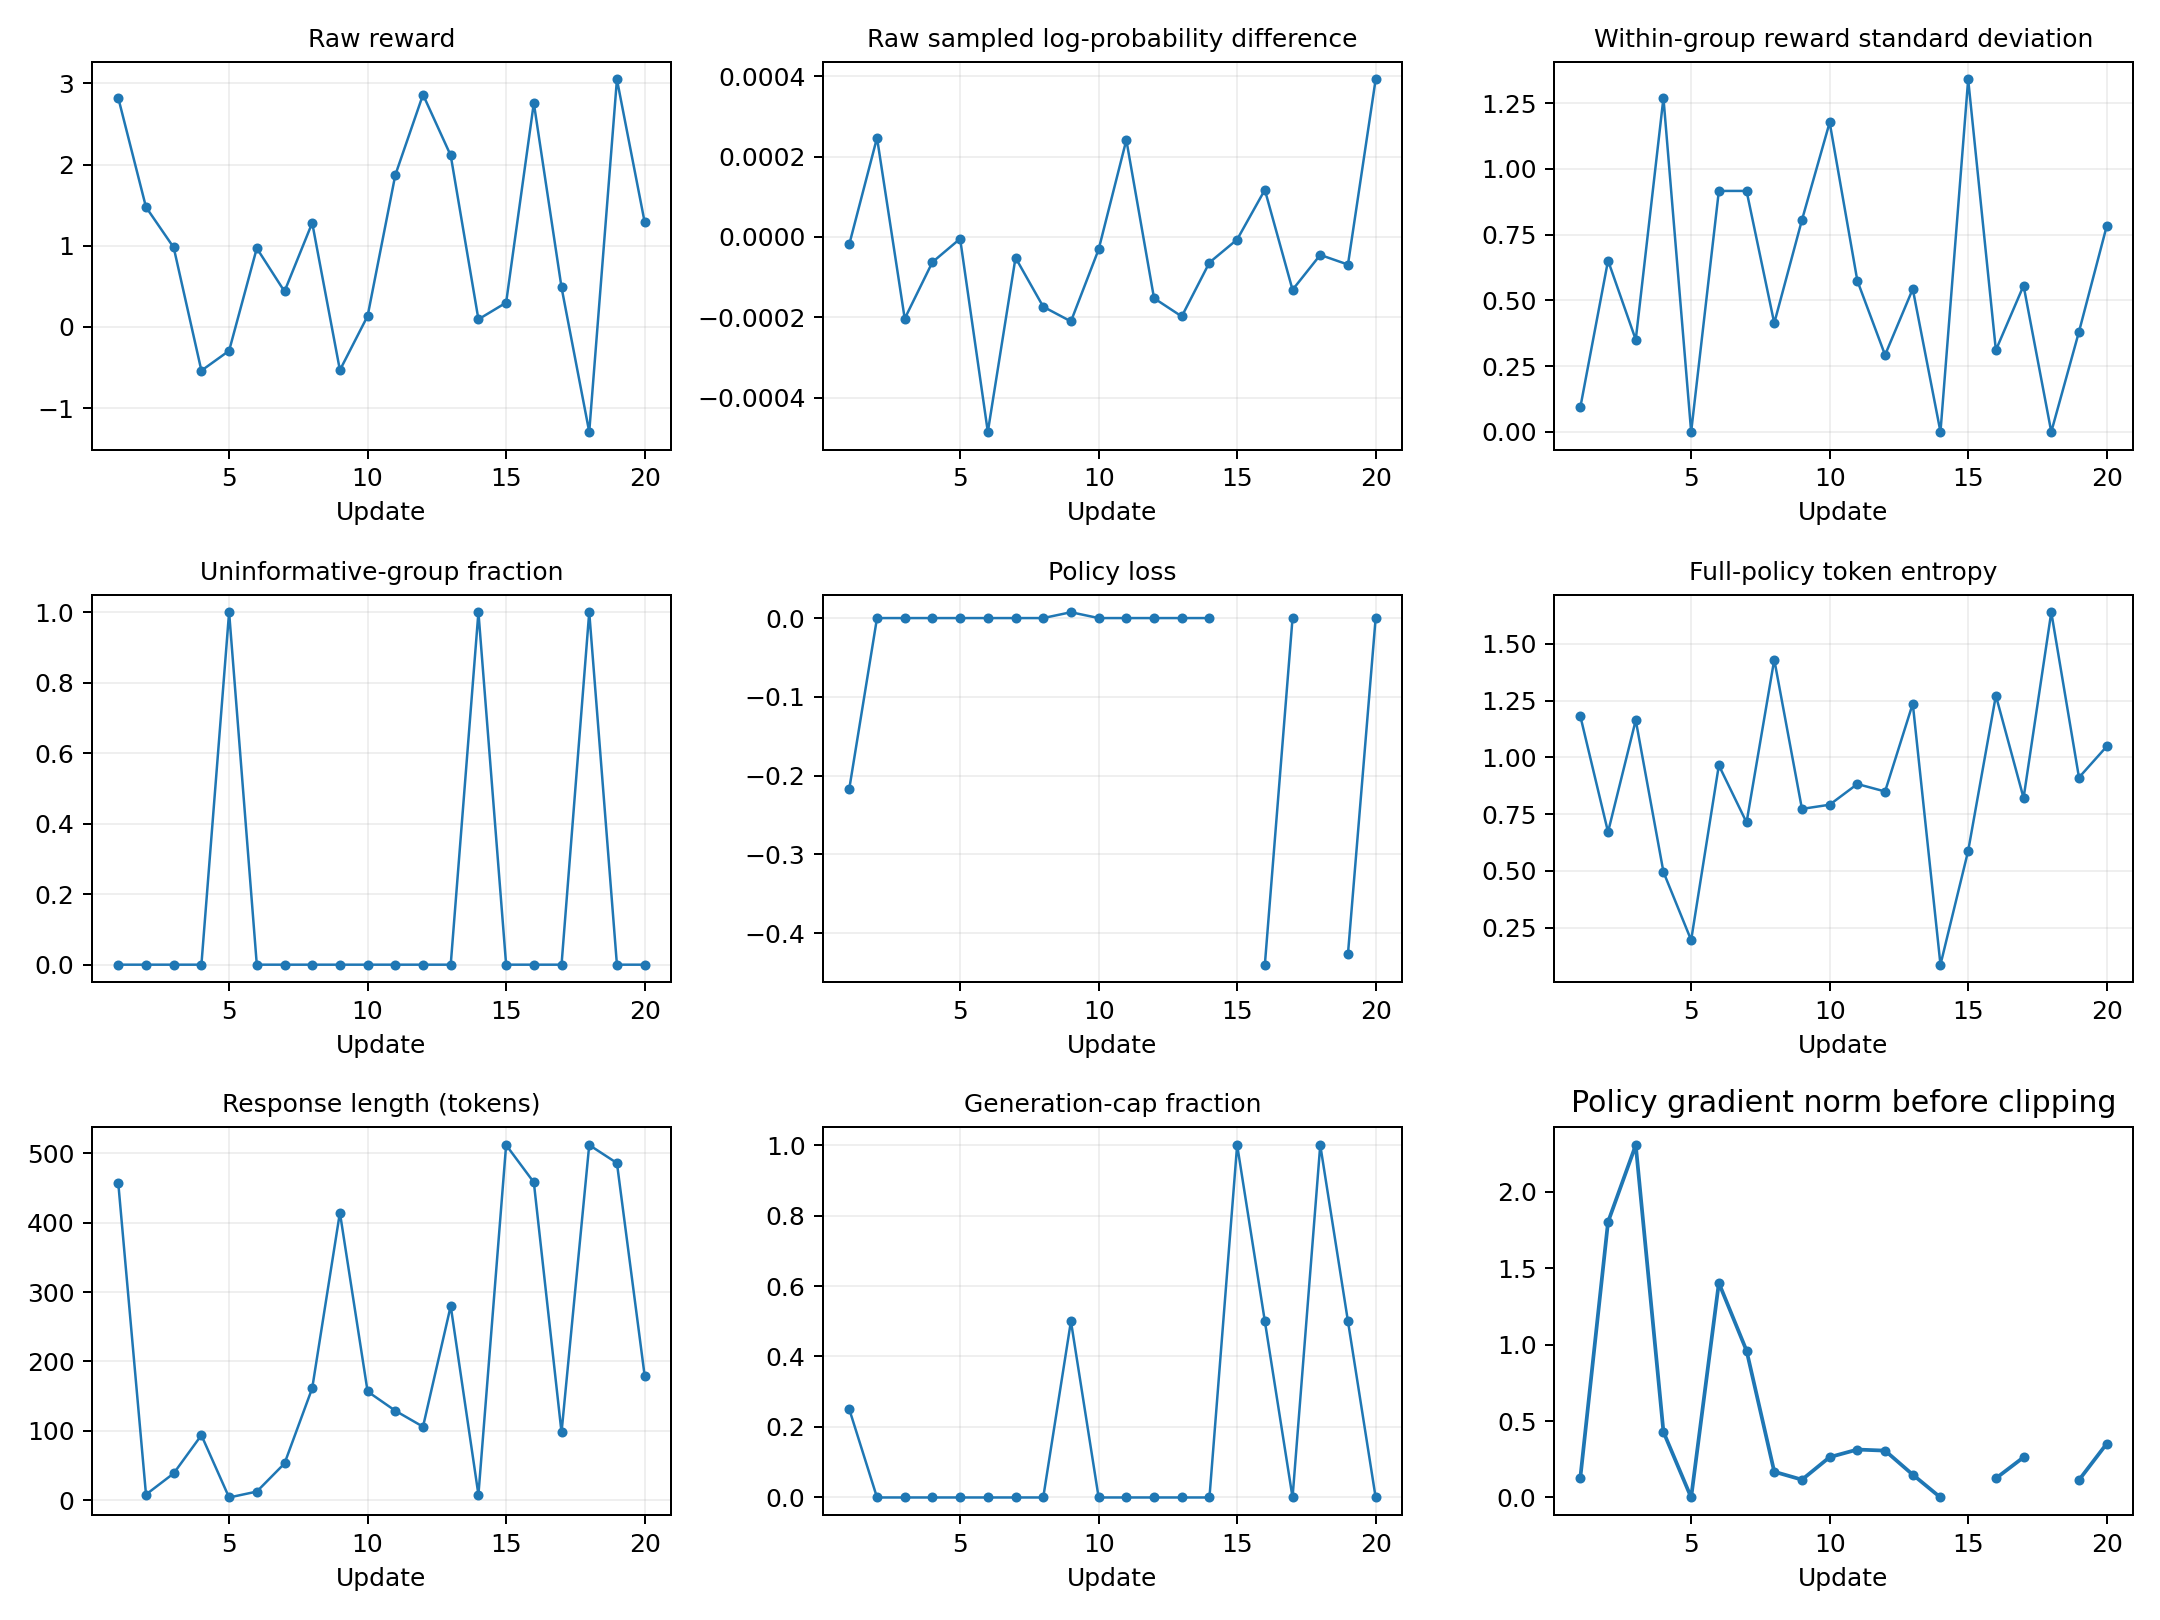

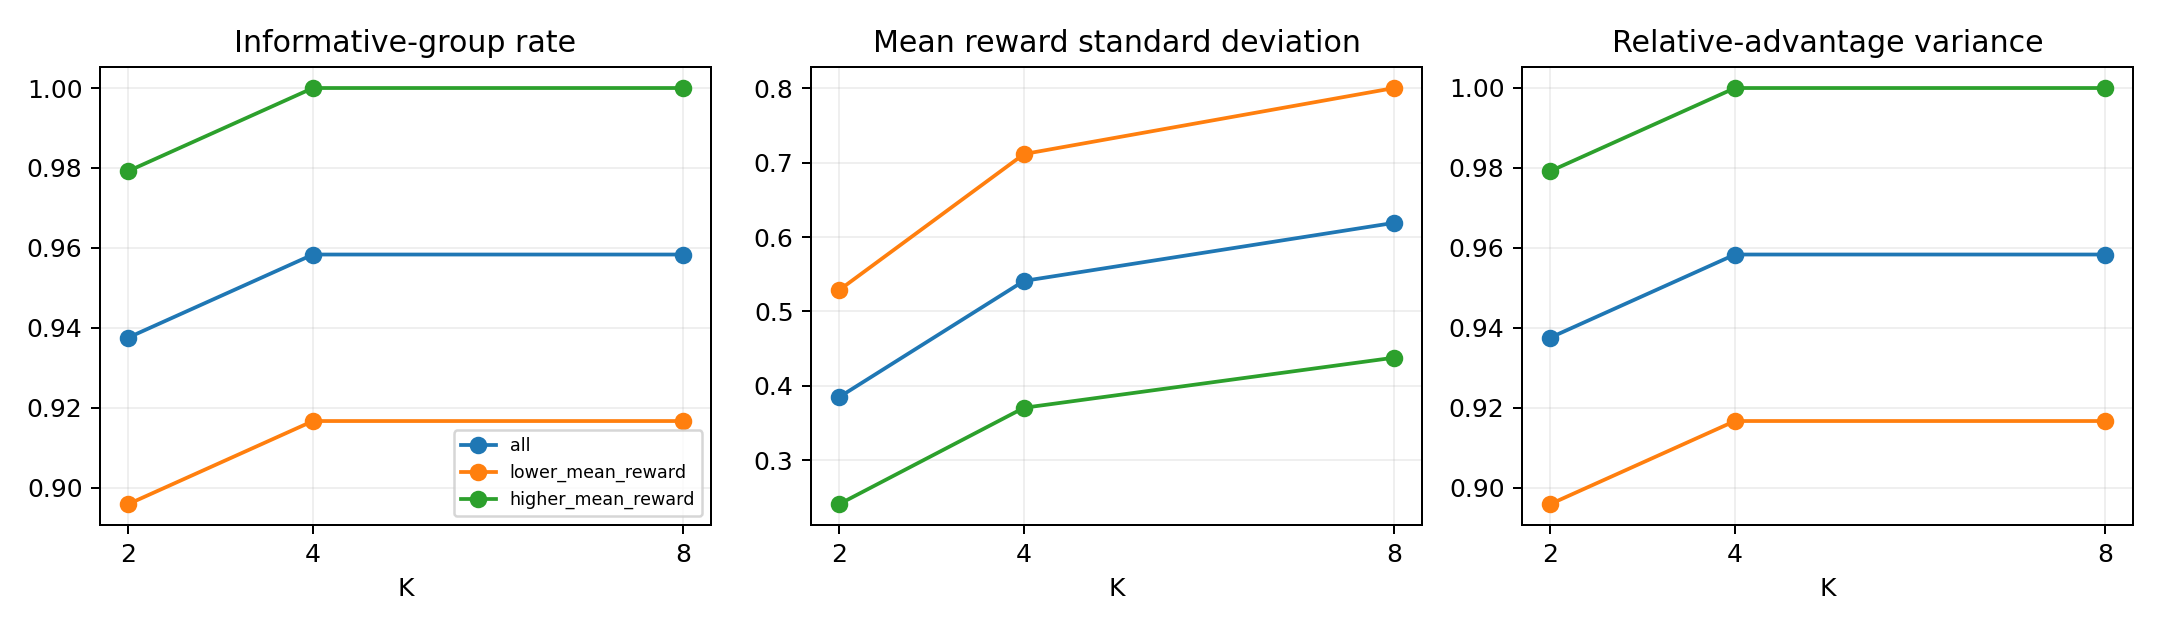

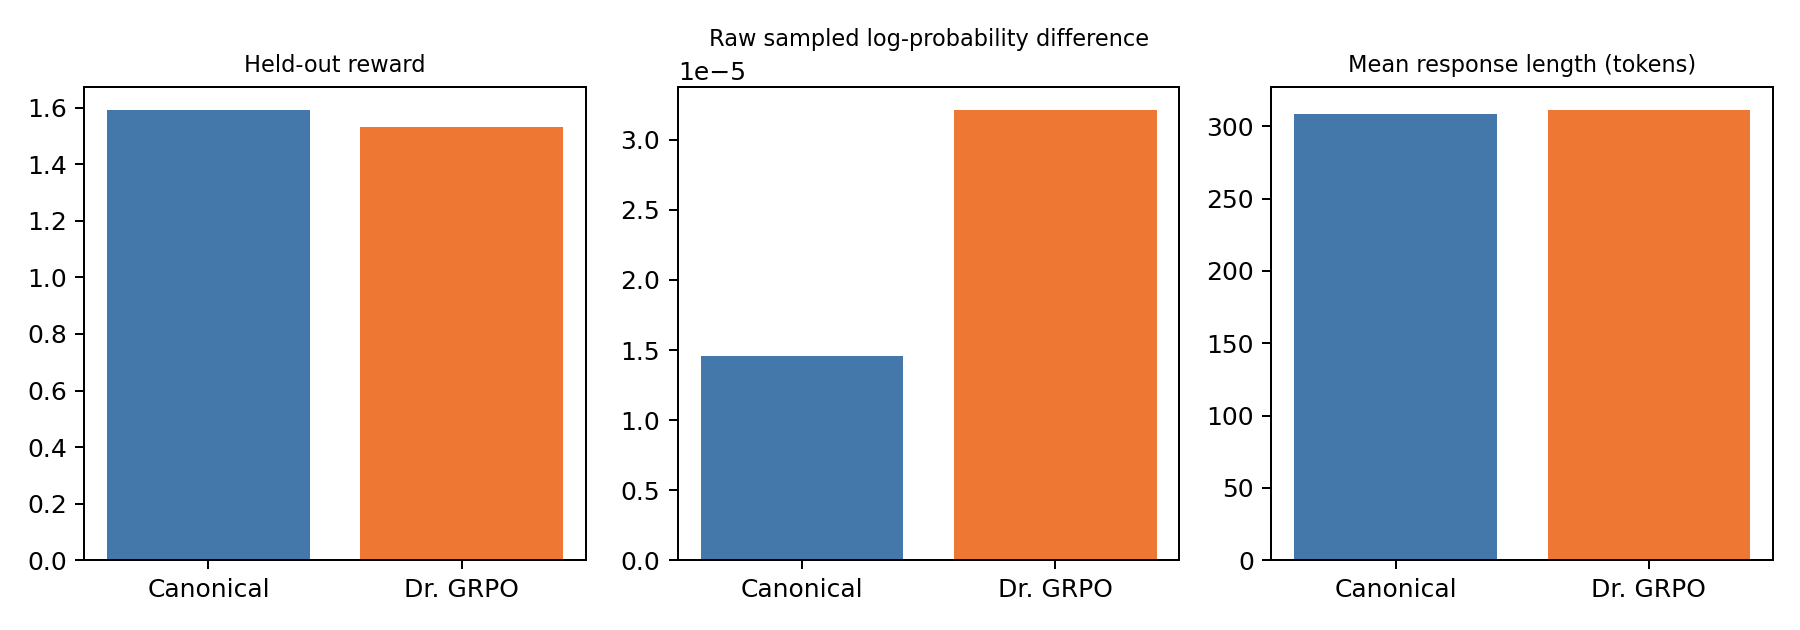

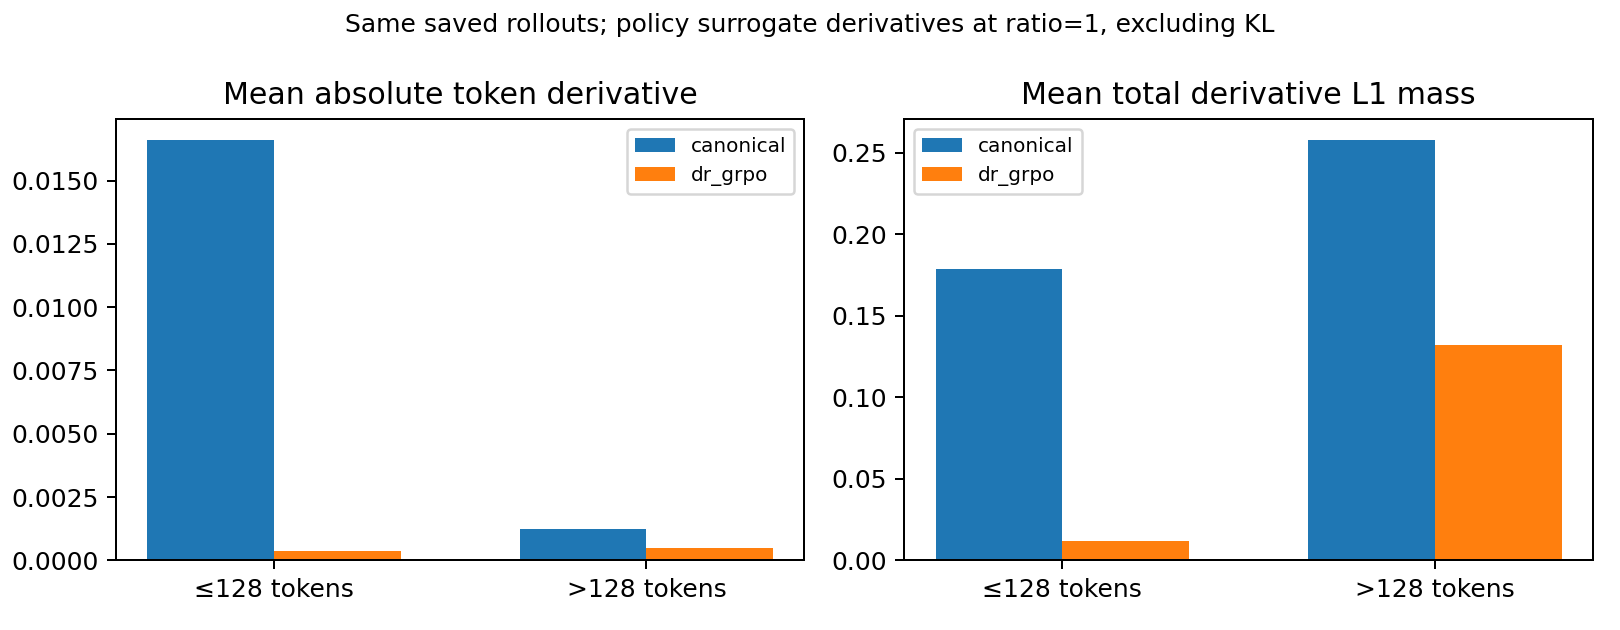

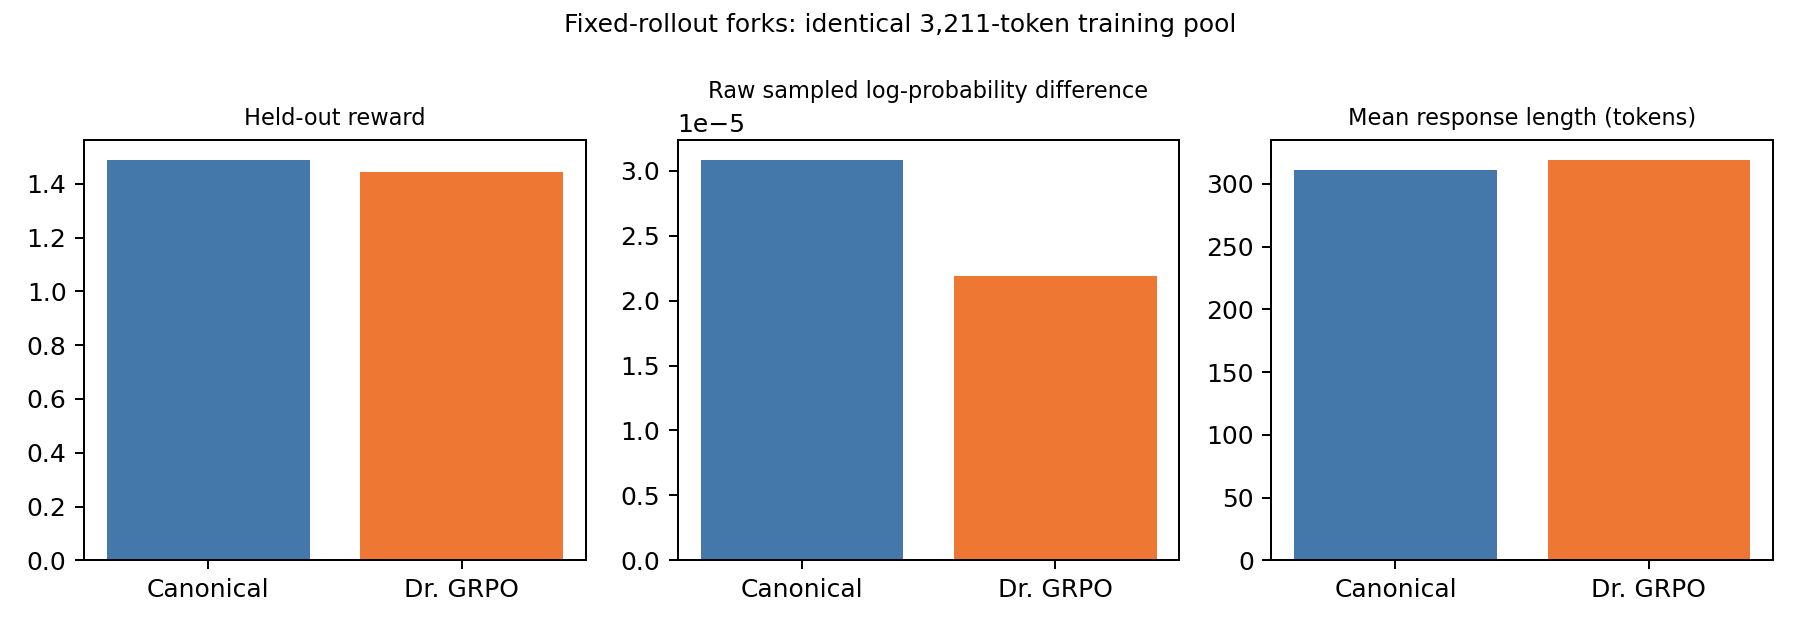

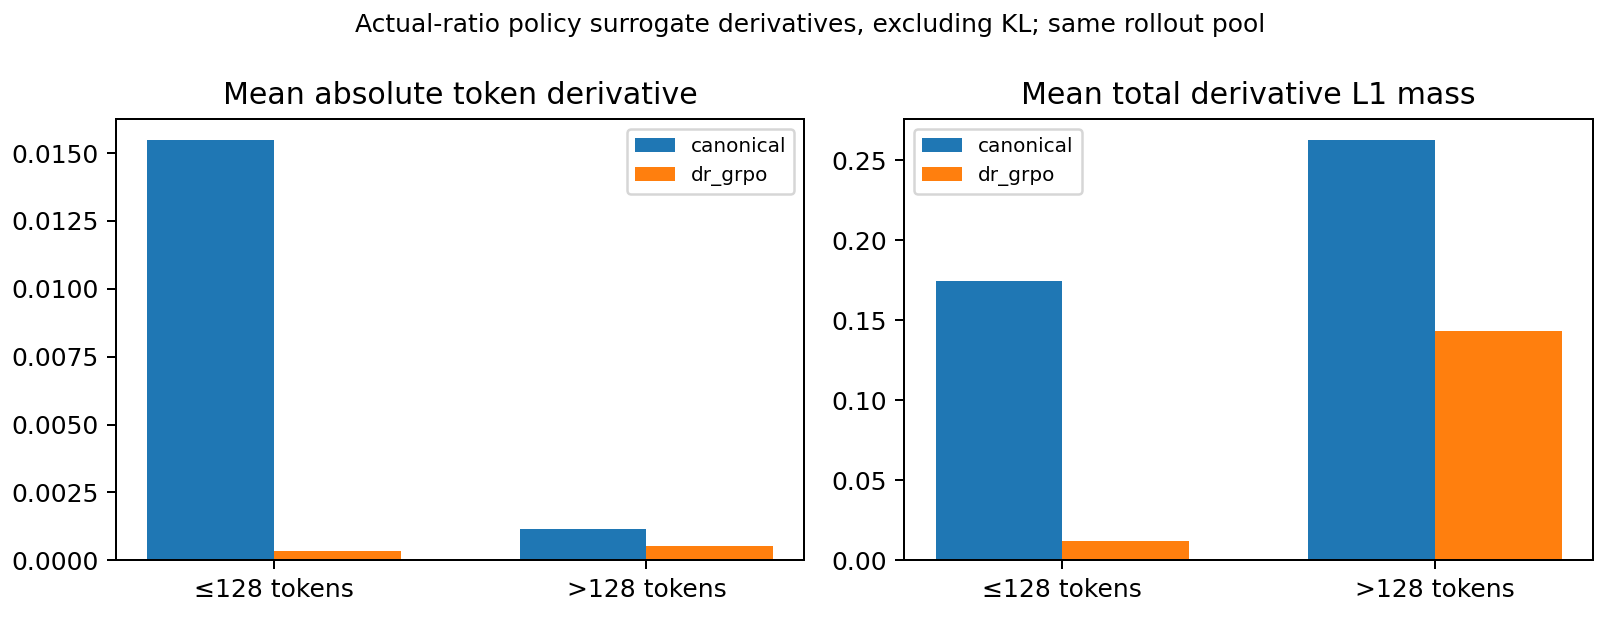

In [5]:
from IPython.display import Image, display

for name in ["task3_standard_training", "task3_group_size",
             "task3_normalization_comparison", "task3_fixed_rollout_normalization",
             "task3_matched_normalization_comparison", "task3_matched_gradient_allocation"]:
    display(Image(filename=f"report/figures/{name}.png"))


In [6]:
import json

original = json.loads((results / "artifact_validation.json").read_text())
matched = json.loads((results / "matched_normalization_validation.json").read_text())
final = json.loads((results / "final_matched_artifact_validation.json").read_text())
print("Original integrity checks:", original["passed"])
print("Matched integrity checks:", matched["passed"], final["passed"])
print("Matched rollout tokens per fork:", matched["exact_generated_token_budget_per_condition"])
print("Matched active-loss tokens per fork:", matched["exact_active_loss_tokens_per_condition"])
print("Protocol:", matched["protocol"])
collection = json.loads((results / "shared_midpoint_rollouts_summary.json").read_text())
print("Shared collection time (seconds):", collection["collection_seconds_this_session"])
print(collection["accounting"])
for item in original["limitations"]:
    print("Original experiment limitation:", item)


Original integrity checks: True
Matched integrity checks: True True
Matched rollout tokens per fork: 3211
Matched active-loss tokens per fork: 2699
Protocol: Fixed-rollout normalization intervention; same frozen-midpoint completions and behavior log probabilities. Later batches are not sampled from updated forks.
Shared collection time (seconds): 99.04259351399998
Completions generated once and reused by both forks. Each fork consumes the exact same tokenized rollout pool; do not count collection cost twice.
Original experiment limitation: Actual generated-token counts differ; the forks share a maximum allowance, not exact token matching.
Original experiment limitation: Raw sampled log-probability differences under tempered/top-p decoding are diagnostics, not unbiased full-policy KL.
Original experiment limitation: Selected-token log-probability derivatives are not model-parameter gradient norms.


In [7]:
# Complete saved responses, selected by extreme reward changes for human review.
candidates = json.loads((results / "matched_qualitative_candidates.json").read_text())
print(candidates["selection_rule"])
SELECTED_ROWS = [81, 1]
for example in candidates["examples"]:
    if example["row_index"] not in SELECTED_ROWS:
        continue
    print(f"\n--- Row {example['row_index']} ---")
    for message in example["prompt_messages"]:
        print(message["role"] + ":", message["content"])
    for name in ["matched_canonical", "matched_dr_grpo"]:
        response = example[name]
        print(f"\n{name}: reward={response['reward']:.4f}, tokens={response['response_length']}, capped={response['hit_generation_cap']}")
        print(response["response"])


Three smallest and three largest matched Dr. GRPO minus matched canonical reward changes; human-review candidates, not representative quality labels.

--- Row 81 ---
user: Can you summarize the Learn How To Academy System scam and why it's a repeated one? Answer according to: Learn How To Academy Scam AGAIN!
A different title for the same game. Diane Fisher. Same exact, same old, work from home link posting online scam. I would like to show you in this post why I am so sure that the Learn How To Academy System is a scam, and a repeated one at that.
Seems as if this scam will never be turned off and it becomes a kind of pain to continually post this Bull*** each time it grows a different head. However, I realize it’s a bit difficult to be discovered. My goal now is to reveal and provide you with proof of my allegations.However, I realize it’s a bit difficult to be discovered. My goal now is to reveal and provide you with proof of my allegations.
It may look a bit different but seriously

In [8]:
# GPU reproduction only. Existing matching completed runs are reused;
# preserve old results/outputs or use a fresh checkout for a new experiment.
RUN_GPU = False
if RUN_GPU:
    import torch
    assert torch.cuda.is_available()
    commands = [
        ["task3_grpo.continue_train", "--config", "configs/grpo.yaml", "--run-name", "standard"],
        ["task3_grpo.compare_normalization", "--config", "configs/grpo.yaml", "--stage", "train"],
        ["task3_grpo.evaluate", "--config", "configs/grpo.yaml", "--adapter", "outputs/task3_grpo/standard", "--name", "standard", "--batch-size", "4"],
        ["task3_grpo.compare_normalization", "--config", "configs/grpo.yaml", "--stage", "evaluate", "--batch-size", "4"],
        ["task3_grpo.compare_normalization", "--config", "configs/grpo.yaml", "--stage", "summarize"],
        ["task3_grpo.matched_normalization", "--config", "configs/grpo.yaml", "--stage", "all"],
        ["task3_grpo.evaluate", "--config", "configs/grpo.yaml", "--adapter", "outputs/task3_grpo/matched_canonical", "--name", "matched_canonical", "--batch-size", "4"],
        ["task3_grpo.evaluate", "--config", "configs/grpo.yaml", "--adapter", "outputs/task3_grpo/matched_dr_grpo", "--name", "matched_dr_grpo", "--batch-size", "4"],
        ["task3_grpo.finalize_matched", "--config", "configs/grpo.yaml"],
    ]
    for args in commands:
        command = [sys.executable, "-u", "-m", *args]
        print("Running:", " ".join(command), flush=True)
        with subprocess.Popen(command, stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
                              text=True, bufsize=1) as process:
            for line in process.stdout:
                print(line, end="", flush=True)
            returncode = process.wait()
        if returncode != 0:
            raise RuntimeError(f"Command failed: {returncode}")
